# Reliance Inc. Census Data Analysis
## Steel Industry Economic Indicators Analysis

**Analysis Date**: October 25, 2025  
**Purpose**: Comprehensive analysis of Census economic indicators for steel price forecasting and demand nowcasting

### Data Sources Analyzed:
1. **Construction Spending (VIP)** - Infrastructure and commercial construction demand
2. **Manufacturers' Shipments (M3)** - Primary metals production and orders
3. **Residential Construction (RES)** - Housing starts and permits
4. **Retail Trade (MRTS)** - Auto sales and building materials demand
5. **Advance Durable Goods (ADVM3)** - Leading indicator for manufacturing demand

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries loaded and configured")

/Users/matthewtonks/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/matplotlib-tf_0ofyc because there was an issue with the default path (/Users/matthewtonks/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


✓ Libraries loaded and configured


In [2]:
# Load extracted Census data
DATA_DIR = Path('extracted_data/census')

# Load all datasets
datasets = {}

try:
    datasets['construction'] = pd.read_csv(DATA_DIR / 'census_construction.csv', parse_dates=['date'])
    print(f"✓ Construction (VIP): {len(datasets['construction']):,} records")
except FileNotFoundError:
    print("✗ Construction data not found")

try:
    datasets['m3'] = pd.read_csv(DATA_DIR / 'census_m3_primary_metals.csv', parse_dates=['date'])
    print(f"✓ Manufacturing (M3): {len(datasets['m3']):,} records")
except FileNotFoundError:
    print("✗ M3 data not found")

try:
    datasets['residential'] = pd.read_csv(DATA_DIR / 'census_res.csv', parse_dates=['date'])
    print(f"✓ Residential Construction (RES): {len(datasets['residential']):,} records")
except FileNotFoundError:
    print("✗ Residential construction data not found")

try:
    datasets['retail'] = pd.read_csv(DATA_DIR / 'census_mrts_selected.csv', parse_dates=['date'])
    print(f"✓ Retail Trade (MRTS): {len(datasets['retail']):,} records")
except FileNotFoundError:
    print("✗ Retail trade data not found")

try:
    datasets['durable_goods'] = pd.read_csv(DATA_DIR / 'census_advm3.csv', parse_dates=['date'])
    print(f"✓ Advance Durable Goods (ADVM3): {len(datasets['durable_goods']):,} records")
except FileNotFoundError:
    print("✗ Advance durable goods data not found")

print(f"\n✓ Total datasets loaded: {len(datasets)}")

✓ Construction (VIP): 36,576 records
✓ Manufacturing (M3): 184,150 records
✓ Residential Construction (RES): 22,528 records
✓ Retail Trade (MRTS): 6,096 records
✓ Advance Durable Goods (ADVM3): 40,960 records

✓ Total datasets loaded: 5


## 1. Data Quality Assessment

In [3]:
# Data quality summary
quality_report = []

for name, df in datasets.items():
    quality_report.append({
        'Dataset': name.title(),
        'Records': len(df),
        'Date Range': f"{df['date'].min().strftime('%Y-%m')} to {df['date'].max().strftime('%Y-%m')}",
        'Missing Values': df.isnull().sum().sum(),
        'Unique Categories': df.filter(like='category').nunique().sum() if any('category' in col for col in df.columns) else 'N/A',
        'Latest Update': df['date'].max().strftime('%Y-%m-%d')
    })

quality_df = pd.DataFrame(quality_report)
print("\n📊 DATA QUALITY SUMMARY")
print("="*80)
display(quality_df)


📊 DATA QUALITY SUMMARY


,Dataset,Records,Date Range,Missing Values,Unique Categories,Latest Update
0,Construction,36576,2015-01 to 2025-07,0,38,2025-07-01
1,M3,184150,2015-01 to 2025-07,0,N/A,2025-07-01
2,Residential,22528,2015-01 to 2025-08,0,8,2025-08-01
3,Retail,6096,2015-01 to 2025-07,0,6,2025-07-01
4,Durable_Goods,40960,2015-01 to 2025-08,0,20,2025-08-01


## 2. Manufacturing Sector Analysis (M3)
### Primary Metals Production and Orders

In [4]:
if 'm3' in datasets:
    m3 = datasets['m3']
    
    # Focus on primary metals (NAICS 331)
    primary_metals = m3[m3['naics_code'].str.startswith('331', na=False)].copy()
    
    # Filter for seasonally adjusted data
    if 'seasonally_adjusted' in primary_metals.columns:
        primary_metals_sa = primary_metals[primary_metals['seasonally_adjusted'] == True]
    else:
        primary_metals_sa = primary_metals
    
    # Summary statistics by indicator type
    print("\n📈 PRIMARY METALS MANUFACTURING INDICATORS")
    print("="*80)
    
    for indicator in primary_metals_sa['indicator'].unique():
        indicator_data = primary_metals_sa[primary_metals_sa['indicator'] == indicator]
        indicator_name = indicator_data['indicator_name'].iloc[0] if len(indicator_data) > 0 else indicator
        
        print(f"\n{indicator_name} ({indicator}):")
        print(f"  Latest Value: ${indicator_data['value_millions'].iloc[-1]:,.0f}M")
        print(f"  6-Month Avg: ${indicator_data['value_millions'].tail(6).mean():,.0f}M")
        print(f"  12-Month Avg: ${indicator_data['value_millions'].tail(12).mean():,.0f}M")
        
        # Calculate year-over-year change
        if len(indicator_data) >= 12:
            yoy_change = ((indicator_data['value_millions'].iloc[-1] / indicator_data['value_millions'].iloc[-12]) - 1) * 100
            print(f"  YoY Change: {yoy_change:+.1f}%")


📈 PRIMARY METALS MANUFACTURING INDICATORS


In [19]:
# Visualization: Manufacturing Indicators Time Series
if 'm3' in datasets and len(primary_metals_sa) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Primary Metals Manufacturing Indicators (NAICS 331)', fontsize=16, fontweight='bold')
    
    indicators_to_plot = ['SM', 'NO', 'UO', 'TI']
    titles = ['Shipments (Monthly)', 'New Orders', 'Unfilled Orders', 'Total Inventories']
    
    for idx, (indicator, title) in enumerate(zip(indicators_to_plot, titles)):
        ax = axes[idx // 2, idx % 2]
        
        data = primary_metals_sa[primary_metals_sa['indicator'] == indicator]
        
        if len(data) > 0:
            # Plot each NAICS category
            for naics in data['naics_code'].unique():
                naics_data = data[data['naics_code'] == naics].sort_values('date')
                ax.plot(naics_data['date'], naics_data['value_millions'], 
                       label=f'NAICS {naics}', linewidth=2, marker='o', markersize=3, alpha=0.7)
            
            ax.set_title(title, fontweight='bold', fontsize=12)
            ax.set_xlabel('Date', fontsize=10)
            ax.set_ylabel('Value (Millions $)', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, f'No data available for {indicator}', 
                   ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Manufacturing indicators visualization complete")

## 3. Construction Spending Analysis (VIP)
### Infrastructure and Commercial Construction Demand

In [6]:
if 'construction' in datasets:
    construction = datasets['construction']
    
    # Filter for seasonally adjusted data
    if 'seasonally_adjusted' in construction.columns:
        construction_sa = construction[construction['seasonally_adjusted'] == True]
    else:
        construction_sa = construction
    
    print("\n🏗️  CONSTRUCTION SPENDING ANALYSIS")
    print("="*80)
    
    # Top construction categories by recent spending
    latest_date = construction_sa['date'].max()
    recent_data = construction_sa[construction_sa['date'] == latest_date]
    
    top_categories = recent_data.nlargest(10, 'value_millions')[['category_code', 'value_millions']]
    
    print(f"\nTop 10 Construction Categories (as of {latest_date.strftime('%Y-%m')}):")
    for idx, row in top_categories.iterrows():
        print(f"  {row['category_code']}: ${row['value_millions']:,.0f}M")
    
    # Calculate growth rates
    print("\n📊 Year-over-Year Growth Rates:")
    for category in top_categories['category_code'].head(5):
        cat_data = construction_sa[construction_sa['category_code'] == category].sort_values('date')
        if len(cat_data) >= 12:
            current = cat_data['value_millions'].iloc[-1]
            previous = cat_data['value_millions'].iloc[-12]
            growth = ((current / previous) - 1) * 100
            print(f"  {category}: {growth:+.1f}%")


🏗️  CONSTRUCTION SPENDING ANALYSIS

Top 10 Construction Categories (as of 2025-07):
  AXXXX: $2,139,110M
  AXXXX: $1,623,269M
  ANRXX: $1,240,425M
  A00XX: $898,686M
  A00XX: $886,533M
  ANRXX: $736,736M
  AXXXX: $515,842M
  ANRXX: $503,689M
  A20IX: $223,053M
  A20IX: $221,837M

📊 Year-over-Year Growth Rates:
  AXXXX: -100.0%
  AXXXX: -100.0%
  ANRXX: +16.7%
  A00XX: +0.0%
  A00XX: +0.0%


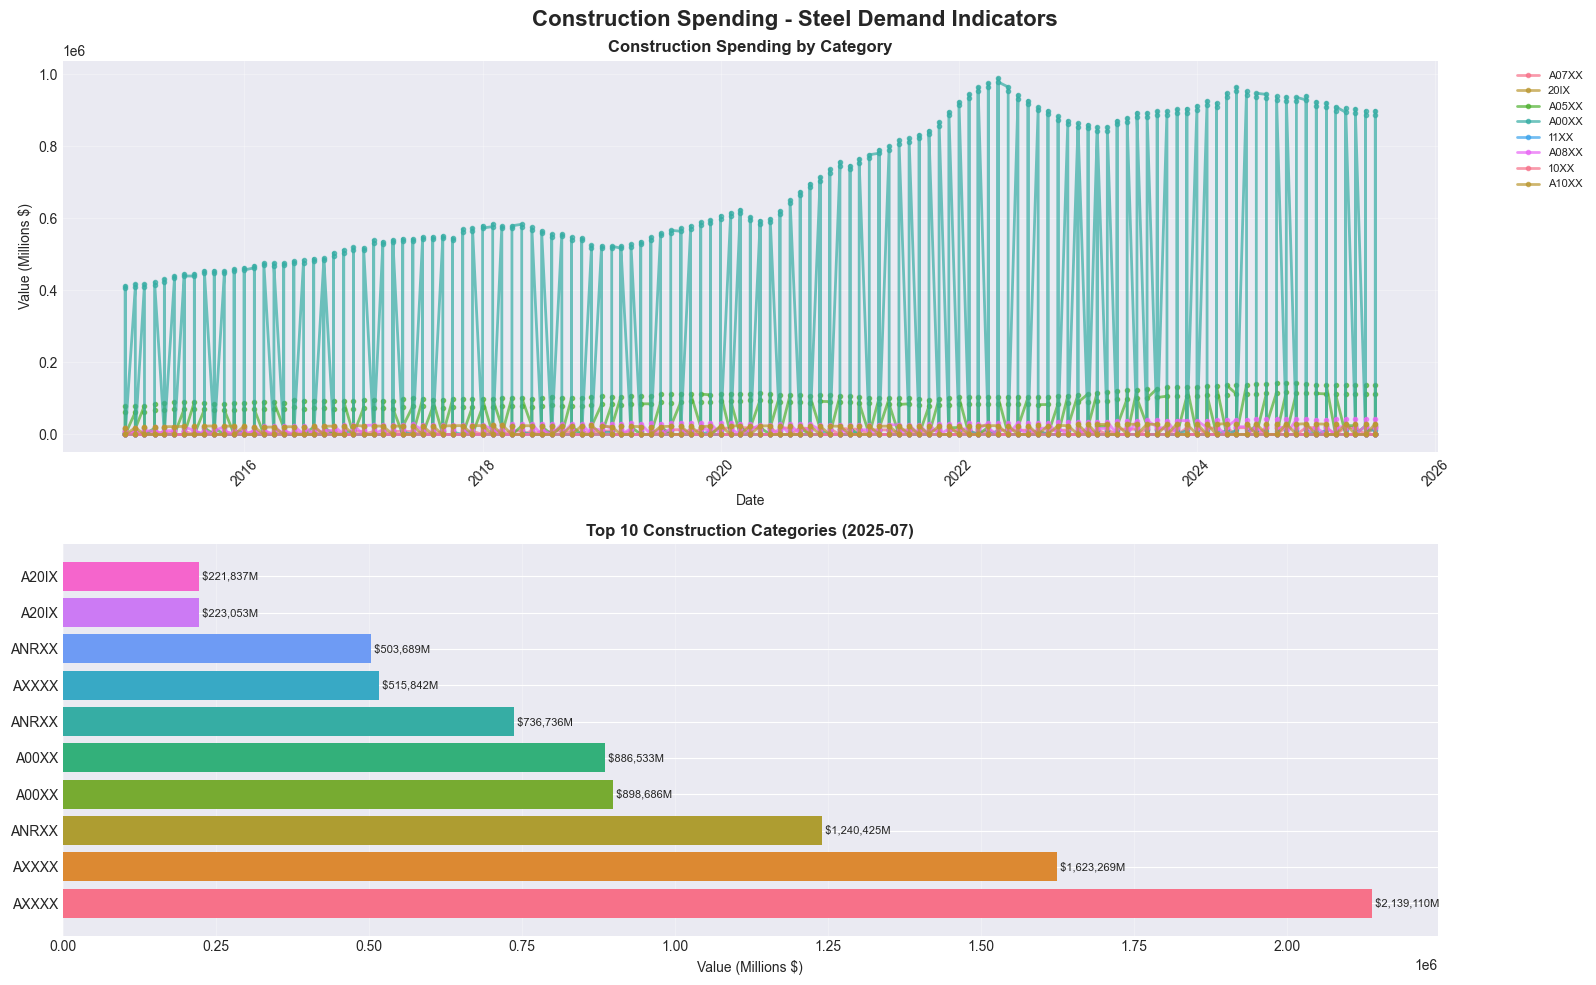


✓ Construction spending visualization complete


In [7]:
# Visualization: Construction Spending Trends
if 'construction' in datasets and len(construction_sa) > 0:
    # Select key construction categories for steel demand
    steel_relevant_categories = construction_sa['category_code'].unique()[:8]  # Top 8 categories
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Construction Spending - Steel Demand Indicators', fontsize=16, fontweight='bold')
    
    # Time series plot
    ax1 = axes[0]
    for category in steel_relevant_categories:
        cat_data = construction_sa[construction_sa['category_code'] == category].sort_values('date')
        if len(cat_data) > 0:
            ax1.plot(cat_data['date'], cat_data['value_millions'], 
                    label=category, linewidth=2, marker='o', markersize=3, alpha=0.7)
    
    ax1.set_title('Construction Spending by Category', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Value (Millions $)', fontsize=10)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Recent spending breakdown
    ax2 = axes[1]
    latest_date = construction_sa['date'].max()
    recent_data = construction_sa[construction_sa['date'] == latest_date]
    top_10 = recent_data.nlargest(10, 'value_millions')
    
    bars = ax2.barh(range(len(top_10)), top_10['value_millions'], color=sns.color_palette("husl", len(top_10)))
    ax2.set_yticks(range(len(top_10)))
    ax2.set_yticklabels(top_10['category_code'])
    ax2.set_xlabel('Value (Millions $)', fontsize=10)
    ax2.set_title(f'Top 10 Construction Categories ({latest_date.strftime("%Y-%m")})', 
                  fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(top_10.iterrows()):
        ax2.text(row['value_millions'], i, f" ${row['value_millions']:,.0f}M", 
                va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Construction spending visualization complete")

## 4. Residential Construction Analysis (RES)
### Housing Starts and Building Permits

In [8]:
if 'residential' in datasets:
    residential = datasets['residential']
    
    # Filter for seasonally adjusted data
    if 'seasonally_adjusted' in residential.columns:
        residential_sa = residential[residential['seasonally_adjusted'] == True]
    else:
        residential_sa = residential
    
    print("\n🏠 RESIDENTIAL CONSTRUCTION ANALYSIS")
    print("="*80)
    
    # Summary by data type
    for data_type in residential_sa['data_type_code'].unique():
        type_data = residential_sa[residential_sa['data_type_code'] == data_type]
        
        print(f"\n{data_type}:")
        print(f"  Latest Value: {type_data['value_units'].iloc[-1]:,.0f} units")
        print(f"  6-Month Avg: {type_data['value_units'].tail(6).mean():,.0f} units")
        print(f"  12-Month Avg: {type_data['value_units'].tail(12).mean():,.0f} units")
        
        if len(type_data) >= 12:
            yoy_change = ((type_data['value_units'].iloc[-1] / type_data['value_units'].iloc[-12]) - 1) * 100
            print(f"  YoY Change: {yoy_change:+.1f}%")


🏠 RESIDENTIAL CONSTRUCTION ANALYSIS

TOTAL:
  Latest Value: 98 units
  6-Month Avg: 236 units
  12-Month Avg: 371 units
  YoY Change: +53.1%

E_TOTAL:
  Latest Value: 7 units
  6-Month Avg: 6 units
  12-Month Avg: 7 units
  YoY Change: -22.2%

MULTI:
  Latest Value: 272 units
  6-Month Avg: 426 units
  12-Month Avg: 520 units
  YoY Change: -49.7%

SINGLE:
  Latest Value: 623 units
  6-Month Avg: 430 units
  12-Month Avg: 390 units
  YoY Change: -15.7%

E_SINGLE:
  Latest Value: 7 units
  6-Month Avg: 8 units
  12-Month Avg: 8 units
  YoY Change: -61.1%

E_MULTI:
  Latest Value: 16 units
  6-Month Avg: 15 units
  12-Month Avg: 15 units
  YoY Change: +0.0%


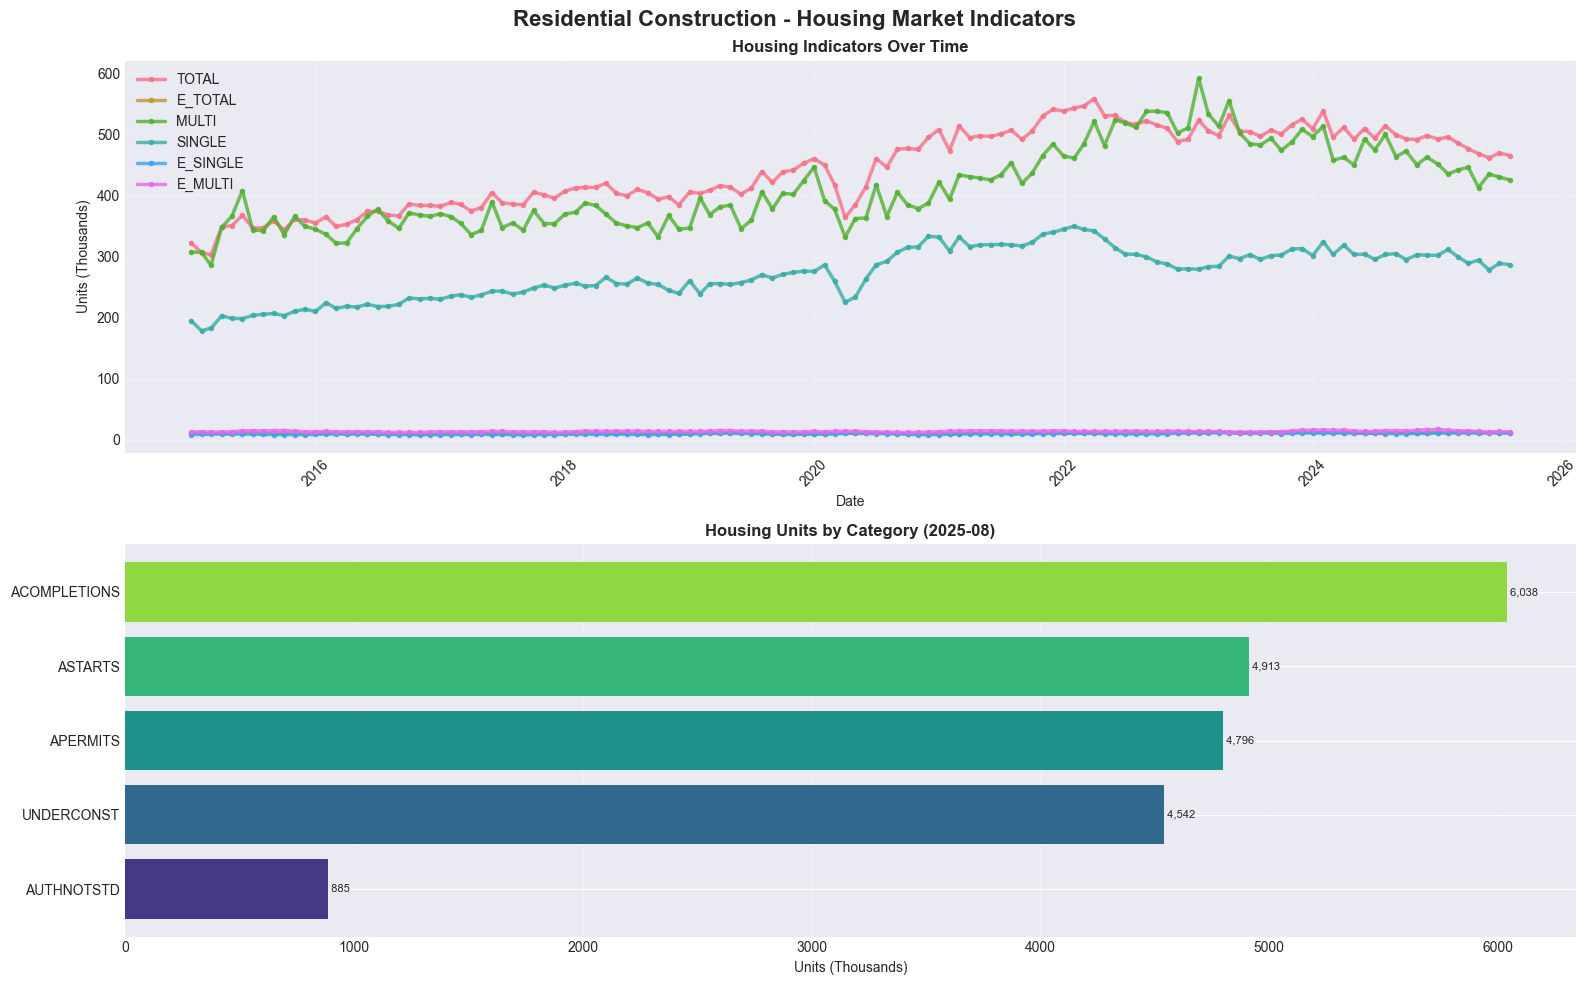


✓ Residential construction visualization complete


In [9]:
# Visualization: Residential Construction Trends
if 'residential' in datasets and len(residential_sa) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Residential Construction - Housing Market Indicators', fontsize=16, fontweight='bold')
    
    # Time series by data type
    ax1 = axes[0]
    for data_type in residential_sa['data_type_code'].unique():
        type_data = residential_sa[residential_sa['data_type_code'] == data_type].sort_values('date')
        if len(type_data) > 0:
            # Aggregate by date to avoid duplicate dates
            type_data_agg = type_data.groupby('date')['value_units'].mean().reset_index()
            ax1.plot(type_data_agg['date'], type_data_agg['value_units'], 
                    label=data_type, linewidth=2.5, marker='o', markersize=3, alpha=0.8)
    
    ax1.set_title('Housing Indicators Over Time', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Units (Thousands)', fontsize=10)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Category breakdown for latest month
    ax2 = axes[1]
    latest_date = residential_sa['date'].max()
    recent_data = residential_sa[residential_sa['date'] == latest_date]
    
    # Group by category and sum values
    category_summary = recent_data.groupby('category_code')['value_units'].sum().sort_values(ascending=True).tail(15)
    
    bars = ax2.barh(range(len(category_summary)), category_summary.values, 
                    color=sns.color_palette("viridis", len(category_summary)))
    ax2.set_yticks(range(len(category_summary)))
    ax2.set_yticklabels(category_summary.index)
    ax2.set_xlabel('Units (Thousands)', fontsize=10)
    ax2.set_title(f'Housing Units by Category ({latest_date.strftime("%Y-%m")})', 
                  fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (cat, val) in enumerate(category_summary.items()):
        ax2.text(val, i, f" {val:,.0f}", va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Residential construction visualization complete")

## 5. Retail Trade Analysis (MRTS)
### Auto Sales and Building Materials Demand

In [10]:
if 'retail' in datasets:
    retail = datasets['retail']
    
    # Filter for seasonally adjusted data
    if 'seasonally_adjusted' in retail.columns:
        retail_sa = retail[retail['seasonally_adjusted'] == True]
    else:
        retail_sa = retail
    
    print("\n🛒 RETAIL TRADE ANALYSIS - Steel Demand Proxies")
    print("="*80)
    
    # Summary by category
    for category in retail_sa['category_code'].unique():
        cat_data = retail_sa[retail_sa['category_code'] == category].sort_values('date')
        cat_name = cat_data['category_name'].iloc[0] if 'category_name' in cat_data.columns else category
        
        print(f"\n{cat_name} ({category}):")
        print(f"  Latest Sales: ${cat_data['value_millions'].iloc[-1]:,.0f}M")
        print(f"  6-Month Avg: ${cat_data['value_millions'].tail(6).mean():,.0f}M")
        print(f"  12-Month Avg: ${cat_data['value_millions'].tail(12).mean():,.0f}M")
        
        if len(cat_data) >= 12:
            yoy_change = ((cat_data['value_millions'].iloc[-1] / cat_data['value_millions'].iloc[-12]) - 1) * 100
            print(f"  YoY Change: {yoy_change:+.1f}%")
        
        # Calculate 3-month moving average
        cat_data['ma_3m'] = cat_data['value_millions'].rolling(window=3).mean()
        trend = "↑ Increasing" if cat_data['ma_3m'].iloc[-1] > cat_data['ma_3m'].iloc[-3] else "↓ Decreasing"
        print(f"  3-Month Trend: {trend}")


🛒 RETAIL TRADE ANALYSIS - Steel Demand Proxies

Motor Vehicle and Parts Dealers (441):
  Latest Sales: $2M
  6-Month Avg: $1M
  12-Month Avg: $44,466M
  YoY Change: +9150.0%
  3-Month Trend: ↑ Increasing

Building Material & Garden Equipment (444):
  Latest Sales: $0M
  6-Month Avg: $6,654M
  12-Month Avg: $13,687M
  YoY Change: -100.0%
  3-Month Trend: ↑ Increasing

Building Material and Supplies Dealers (4441):
  Latest Sales: $0M
  6-Month Avg: $5,720M
  12-Month Avg: $8,621M
  YoY Change: -100.0%
  3-Month Trend: ↑ Increasing


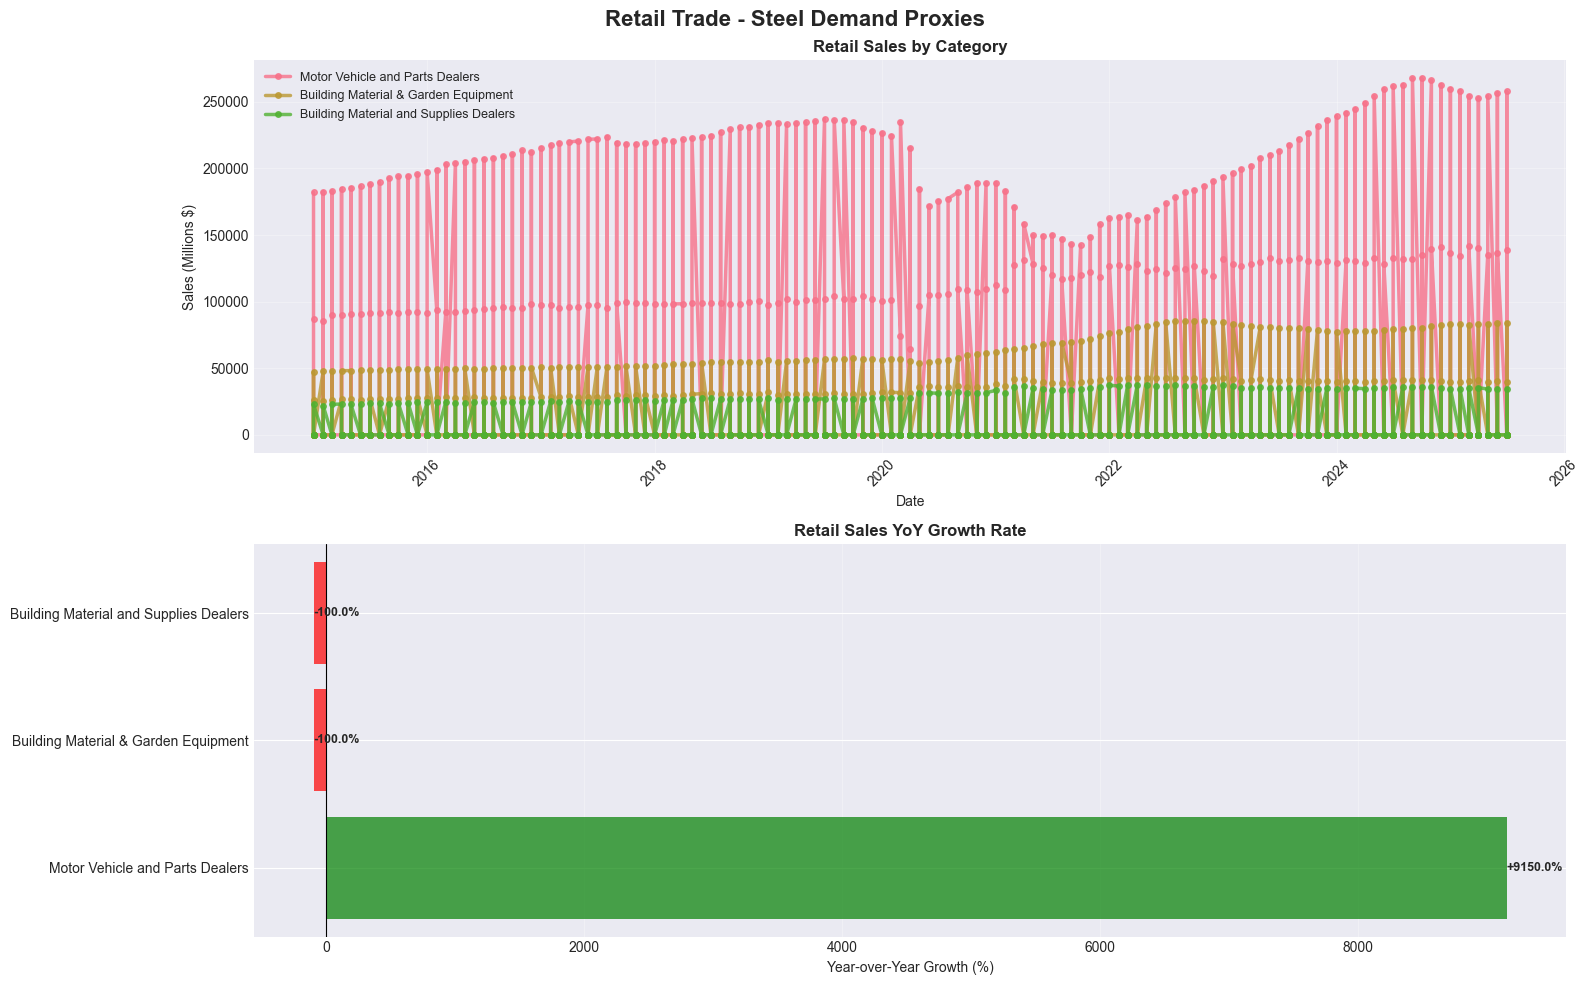


✓ Retail trade visualization complete


In [11]:
# Visualization: Retail Trade Trends
if 'retail' in datasets and len(retail_sa) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Retail Trade - Steel Demand Proxies', fontsize=16, fontweight='bold')
    
    # Time series plot
    ax1 = axes[0]
    for category in retail_sa['category_code'].unique():
        cat_data = retail_sa[retail_sa['category_code'] == category].sort_values('date')
        cat_name = cat_data['category_name'].iloc[0] if 'category_name' in cat_data.columns else category
        
        ax1.plot(cat_data['date'], cat_data['value_millions'], 
                label=cat_name, linewidth=2.5, marker='o', markersize=4, alpha=0.8)
    
    ax1.set_title('Retail Sales by Category', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Sales (Millions $)', fontsize=10)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Year-over-year growth rates
    ax2 = axes[1]
    growth_rates = []
    categories = []
    
    for category in retail_sa['category_code'].unique():
        cat_data = retail_sa[retail_sa['category_code'] == category].sort_values('date')
        cat_name = cat_data['category_name'].iloc[0] if 'category_name' in cat_data.columns else category
        
        if len(cat_data) >= 12:
            current = cat_data['value_millions'].iloc[-1]
            previous = cat_data['value_millions'].iloc[-12]
            growth = ((current / previous) - 1) * 100
            growth_rates.append(growth)
            categories.append(cat_name)
    
    colors = ['green' if g > 0 else 'red' for g in growth_rates]
    bars = ax2.barh(range(len(categories)), growth_rates, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(categories)))
    ax2.set_yticklabels(categories)
    ax2.set_xlabel('Year-over-Year Growth (%)', fontsize=10)
    ax2.set_title('Retail Sales YoY Growth Rate', fontweight='bold', fontsize=12)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, growth in enumerate(growth_rates):
        label_x = growth + (1 if growth > 0 else -1)
        ax2.text(label_x, i, f"{growth:+.1f}%", va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Retail trade visualization complete")

## 6. Advance Durable Goods Analysis (ADVM3)
### Leading Indicator for Manufacturing Demand

In [12]:
if 'durable_goods' in datasets:
    durable = datasets['durable_goods']
    
    # Filter for seasonally adjusted data
    if 'seasonally_adjusted' in durable.columns:
        durable_sa = durable[durable['seasonally_adjusted'] == True]
    else:
        durable_sa = durable
    
    print("\n📦 ADVANCE DURABLE GOODS REPORT - Leading Indicators")
    print("="*80)
    
    # Summary by indicator type
    for indicator in durable_sa['indicator'].unique():
        indicator_data = durable_sa[durable_sa['indicator'] == indicator].sort_values('date')
        indicator_name = indicator_data['indicator_name'].iloc[0] if len(indicator_data) > 0 else indicator
        
        print(f"\n{indicator_name} ({indicator}):")
        
        # Overall summary
        total_recent = indicator_data.groupby('date')['value_millions'].sum().tail(1).values[0]
        print(f"  Latest Total: ${total_recent:,.0f}M")
        
        # Top categories
        latest_date = indicator_data['date'].max()
        latest_data = indicator_data[indicator_data['date'] == latest_date]
        top_5 = latest_data.nlargest(5, 'value_millions')[['category_code', 'value_millions']]
        
        print(f"  Top 5 Categories ({latest_date.strftime('%Y-%m')}):")
        for idx, row in top_5.iterrows():
            print(f"    {row['category_code']}: ${row['value_millions']:,.0f}M")


📦 ADVANCE DURABLE GOODS REPORT - Leading Indicators

MPCUO (MPCUO):
  Latest Total: $8M
  Top 5 Categories (2025-08):
    DAP: $2M
    36S: $1M
    NAP: $1M
    MDM: $1M
    MTU: $1M

MPCVS (MPCVS):
  Latest Total: $-7M
  Top 5 Categories (2025-08):
    34X: $2M
    MVP: $0M
    DEF: $0M
    34S: $0M
    ODG: $0M

New Orders (NO):
  Latest Total: $1,741,457M
  Top 5 Categories (2025-08):
    MDM: $312,059M
    DXD: $290,655M
    MTU: $222,908M
    DXT: $201,872M
    TCG: $110,750M

TI (TI):
  Latest Total: $3,528,050M
  Top 5 Categories (2025-08):
    MDM: $590,760M
    DXD: $557,588M
    MTU: $473,513M
    DXT: $402,559M
    TCG: $275,962M

Unfilled Orders (UO):
  Latest Total: $9,490,474M
  Top 5 Categories (2025-08):
    MTU: $1,479,022M
    MDM: $1,479,022M
    DXD: $1,231,040M
    TCG: $1,082,340M
    36S: $919,136M

VS (VS):
  Latest Total: $1,705,610M
  Top 5 Categories (2025-08):
    MDM: $307,510M
    DXD: $289,303M
    MTU: $213,307M
    DXT: $205,516M
    TCG: $104,672M

MP

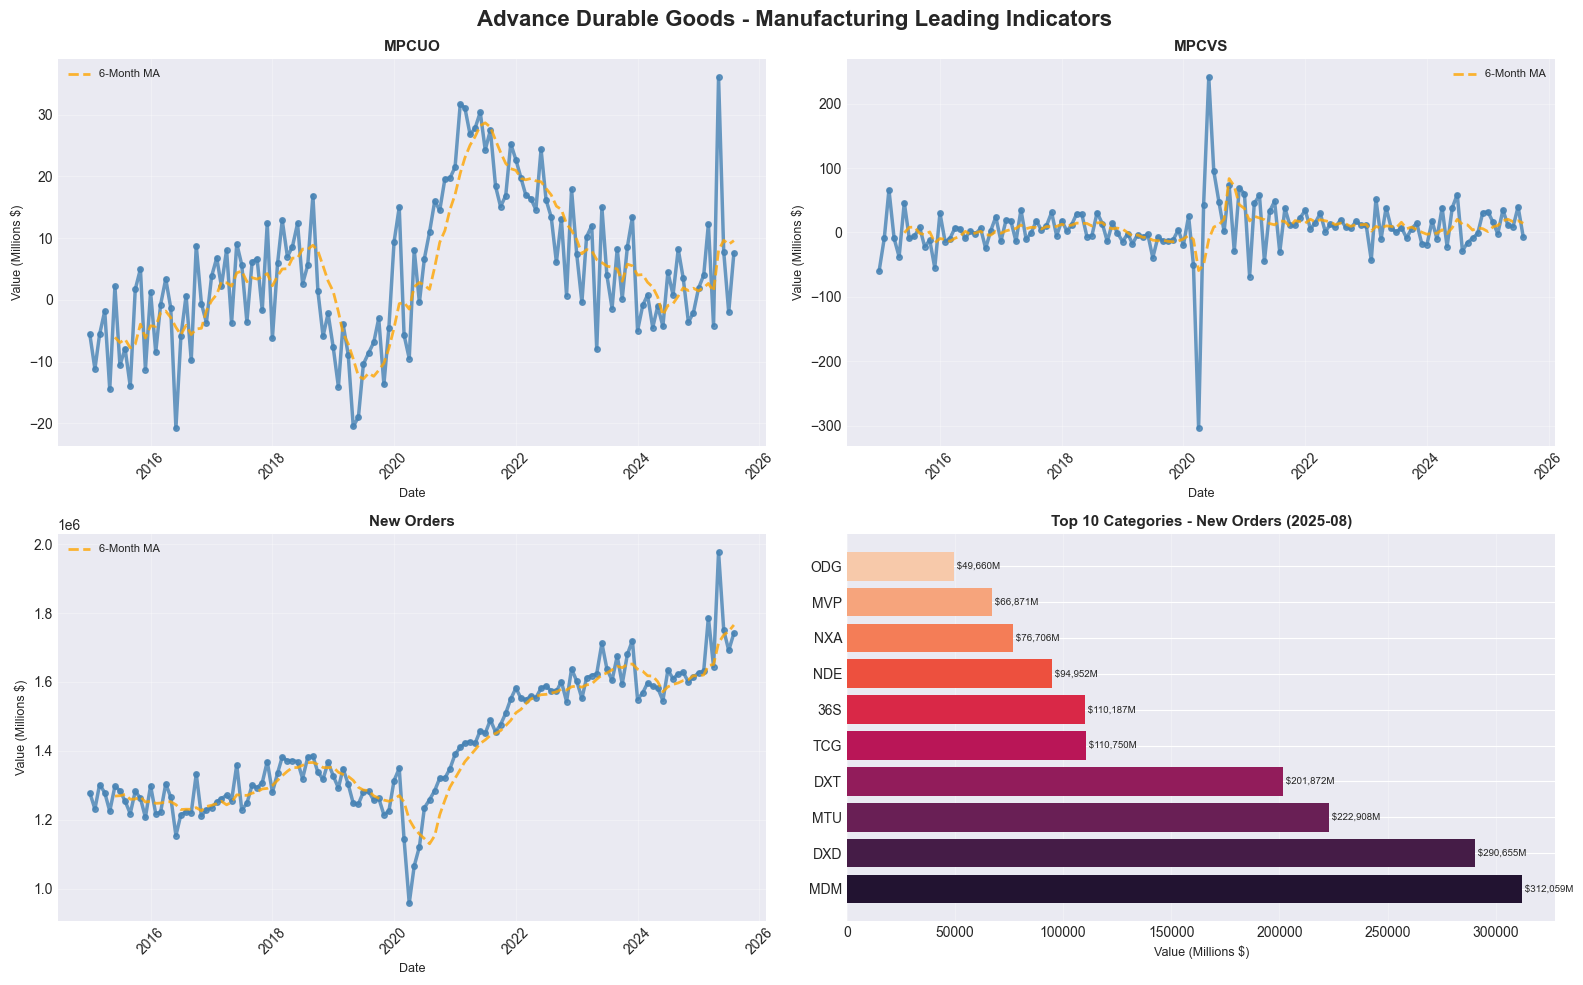


✓ Advance durable goods visualization complete


In [13]:
# Visualization: Advance Durable Goods Trends
if 'durable_goods' in datasets and len(durable_sa) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Advance Durable Goods - Manufacturing Leading Indicators', fontsize=16, fontweight='bold')
    
    indicators = durable_sa['indicator'].unique()[:3]  # Focus on top 3 indicators
    
    # Time series for each indicator
    for idx, indicator in enumerate(indicators):
        if idx >= 3:
            break
            
        ax = axes[idx // 2, idx % 2]
        
        indicator_data = durable_sa[durable_sa['indicator'] == indicator]
        indicator_name = indicator_data['indicator_name'].iloc[0] if len(indicator_data) > 0 else indicator
        
        # Aggregate by date (sum across all categories)
        time_series = indicator_data.groupby('date')['value_millions'].sum().reset_index()
        time_series = time_series.sort_values('date')
        
        ax.plot(time_series['date'], time_series['value_millions'], 
               linewidth=2.5, marker='o', markersize=4, color='steelblue', alpha=0.8)
        
        # Add 6-month moving average
        time_series['ma_6m'] = time_series['value_millions'].rolling(window=6).mean()
        ax.plot(time_series['date'], time_series['ma_6m'], 
               linewidth=2, linestyle='--', color='orange', label='6-Month MA', alpha=0.8)
        
        ax.set_title(f'{indicator_name}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Value (Millions $)', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # Category breakdown for latest month (bottom right)
    ax = axes[1, 1]
    latest_date = durable_sa['date'].max()
    latest_data = durable_sa[(durable_sa['date'] == latest_date) & (durable_sa['indicator'] == 'NO')]  # New Orders
    
    if len(latest_data) > 0:
        top_10 = latest_data.nlargest(10, 'value_millions')
        
        bars = ax.barh(range(len(top_10)), top_10['value_millions'], 
                      color=sns.color_palette("rocket", len(top_10)))
        ax.set_yticks(range(len(top_10)))
        ax.set_yticklabels(top_10['category_code'])
        ax.set_xlabel('Value (Millions $)', fontsize=9)
        ax.set_title(f'Top 10 Categories - New Orders ({latest_date.strftime("%Y-%m")})', 
                    fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.3, axis='x')
        
        for i, (idx, row) in enumerate(top_10.iterrows()):
            ax.text(row['value_millions'], i, f" ${row['value_millions']:,.0f}M", 
                   va='center', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Advance durable goods visualization complete")

## 7. Cross-Indicator Analysis
### Composite Steel Demand Index

In [14]:
# Create composite steel demand index from available indicators
print("\n🔗 COMPOSITE STEEL DEMAND INDEX")
print("="*80)

# Prepare time series for each component
components = {}

# Manufacturing new orders (if available)
if 'm3' in datasets:
    m3_no = datasets['m3'][
        (datasets['m3']['indicator'] == 'NO') & 
        (datasets['m3']['naics_code'].str.startswith('331', na=False))
    ].groupby('date')['value_millions'].sum().reset_index()
    m3_no.columns = ['date', 'm3_new_orders']
    components['m3'] = m3_no
    print(f"✓ Manufacturing New Orders: {len(m3_no)} months")

# Construction spending (if available)
if 'construction' in datasets:
    construction_total = datasets['construction'].groupby('date')['value_millions'].sum().reset_index()
    construction_total.columns = ['date', 'construction_spending']
    components['construction'] = construction_total
    print(f"✓ Construction Spending: {len(construction_total)} months")

# Housing starts (if available)
if 'residential' in datasets:
    housing = datasets['residential'].groupby('date')['value_units'].sum().reset_index()
    housing.columns = ['date', 'housing_units']
    components['housing'] = housing
    print(f"✓ Housing Units: {len(housing)} months")

# Auto sales proxy (if available)
if 'retail' in datasets:
    auto_sales = datasets['retail'][
        datasets['retail']['category_code'] == '441'
    ].groupby('date')['value_millions'].sum().reset_index()
    auto_sales.columns = ['date', 'auto_sales']
    components['auto'] = auto_sales
    print(f"✓ Auto Sales: {len(auto_sales)} months")

# Merge all components
if components:
    composite_df = None
    for name, df in components.items():
        if composite_df is None:
            composite_df = df
        else:
            composite_df = pd.merge(composite_df, df, on='date', how='outer')
    
    composite_df = composite_df.sort_values('date')
    
    # Normalize each component (scale to 0-100)
    for col in composite_df.columns:
        if col != 'date':
            min_val = composite_df[col].min()
            max_val = composite_df[col].max()
            composite_df[f'{col}_normalized'] = ((composite_df[col] - min_val) / (max_val - min_val)) * 100
    
    # Calculate composite index (equal weights for simplicity)
    normalized_cols = [col for col in composite_df.columns if col.endswith('_normalized')]
    composite_df['steel_demand_index'] = composite_df[normalized_cols].mean(axis=1)
    
    print(f"\n✓ Composite index created with {len(components)} indicators")
    print(f"  Date range: {composite_df['date'].min().strftime('%Y-%m')} to {composite_df['date'].max().strftime('%Y-%m')}")
    print(f"  Current index value: {composite_df['steel_demand_index'].iloc[-1]:.1f}")
    print(f"  6-month average: {composite_df['steel_demand_index'].tail(6).mean():.1f}")
    print(f"  12-month average: {composite_df['steel_demand_index'].tail(12).mean():.1f}")
else:
    print("\n✗ Insufficient data to create composite index")


🔗 COMPOSITE STEEL DEMAND INDEX
✓ Manufacturing New Orders: 0 months
✓ Construction Spending: 127 months
✓ Housing Units: 128 months
✓ Auto Sales: 0 months

✓ Composite index created with 4 indicators
  Date range: 2015-01 to 2025-08
  Current index value: 64.3
  6-month average: 78.2
  12-month average: 81.7


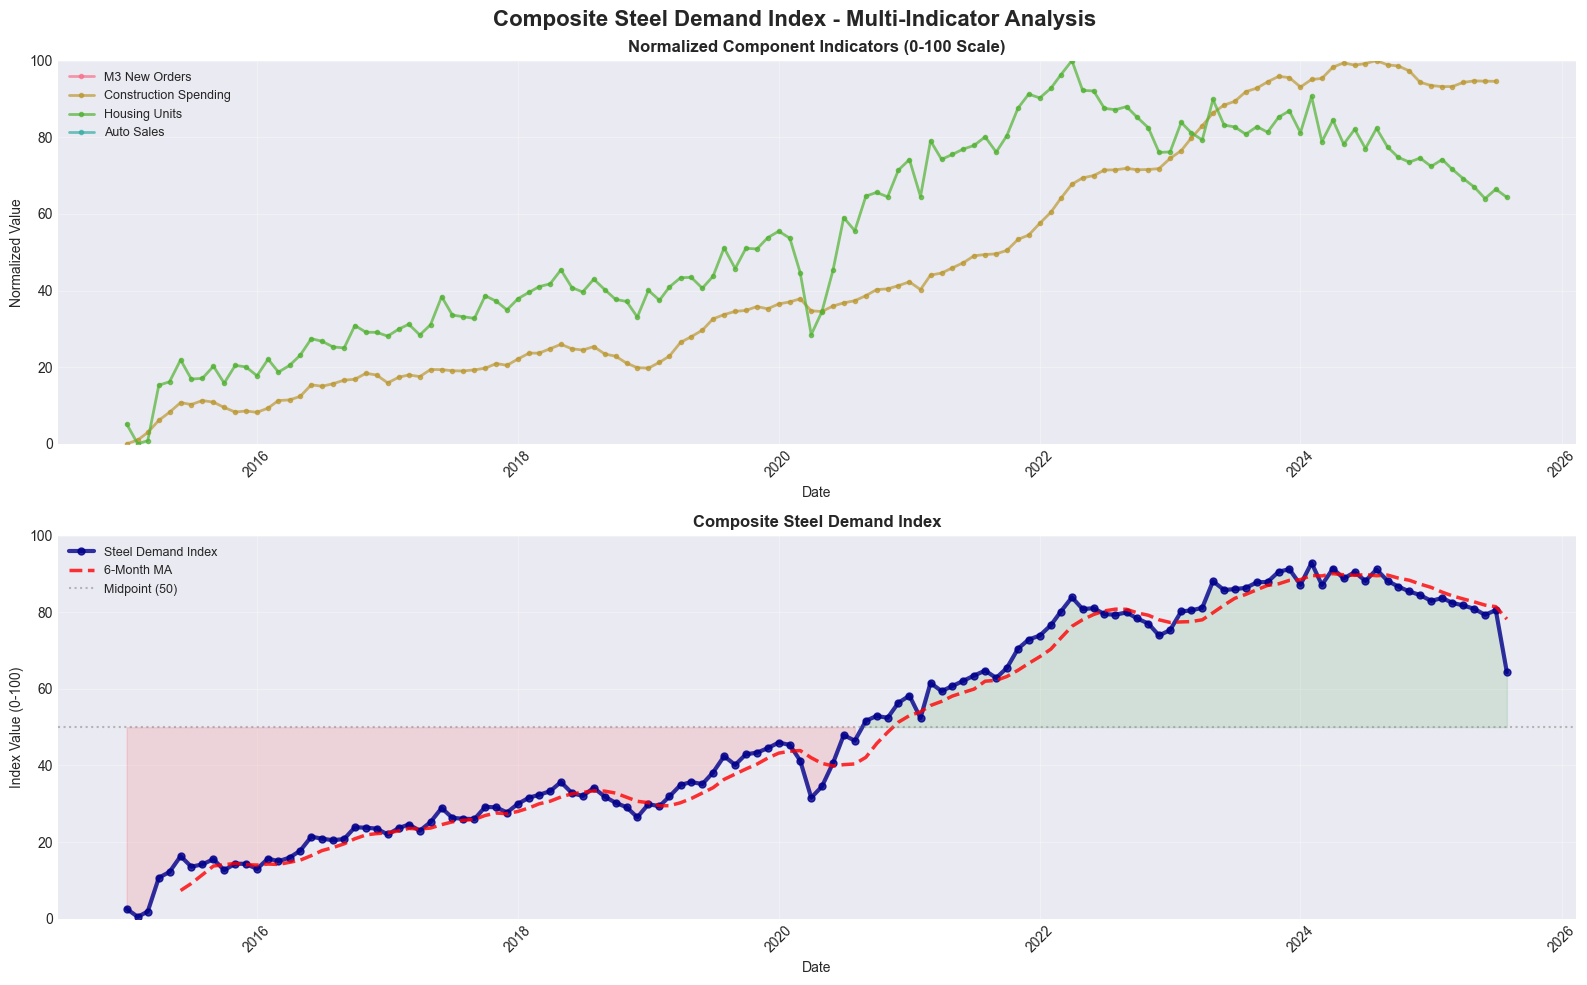


✓ Composite index visualization complete


In [15]:
# Visualization: Composite Steel Demand Index
if 'composite_df' in locals() and composite_df is not None:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Composite Steel Demand Index - Multi-Indicator Analysis', fontsize=16, fontweight='bold')
    
    # Normalized component trends
    ax1 = axes[0]
    for col in normalized_cols:
        component_name = col.replace('_normalized', '').replace('_', ' ').title()
        ax1.plot(composite_df['date'], composite_df[col], 
                label=component_name, linewidth=2, marker='o', markersize=3, alpha=0.7)
    
    ax1.set_title('Normalized Component Indicators (0-100 Scale)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Normalized Value', fontsize=10)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 100)
    
    # Composite index with trend
    ax2 = axes[1]
    ax2.plot(composite_df['date'], composite_df['steel_demand_index'], 
            linewidth=3, marker='o', markersize=5, color='darkblue', label='Steel Demand Index', alpha=0.8)
    
    # Add 6-month moving average
    composite_df['index_ma_6m'] = composite_df['steel_demand_index'].rolling(window=6).mean()
    ax2.plot(composite_df['date'], composite_df['index_ma_6m'], 
            linewidth=2.5, linestyle='--', color='red', label='6-Month MA', alpha=0.8)
    
    # Add reference line at 50 (midpoint)
    ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='Midpoint (50)')
    
    ax2.set_title('Composite Steel Demand Index', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Date', fontsize=10)
    ax2.set_ylabel('Index Value (0-100)', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 100)
    
    # Add shaded regions for expansion/contraction
    ax2.fill_between(composite_df['date'], 50, composite_df['steel_demand_index'], 
                     where=(composite_df['steel_demand_index'] >= 50), 
                     color='green', alpha=0.1, label='Above Average')
    ax2.fill_between(composite_df['date'], composite_df['steel_demand_index'], 50,
                     where=(composite_df['steel_demand_index'] < 50), 
                     color='red', alpha=0.1, label='Below Average')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Composite index visualization complete")

## 8. Correlation Analysis
### Understanding Relationships Between Indicators

In [16]:
# Correlation analysis between indicators
if 'composite_df' in locals() and composite_df is not None:
    print("\n🔗 CORRELATION ANALYSIS")
    print("="*80)
    
    # Select numeric columns for correlation
    corr_cols = [col for col in composite_df.columns if col not in ['date', 'steel_demand_index', 'index_ma_6m'] and not col.endswith('_normalized')]
    
    if len(corr_cols) > 1:
        corr_df = composite_df[corr_cols].dropna()
        
        if len(corr_df) > 0:
            correlation_matrix = corr_df.corr()
            
            # Visualization: Correlation heatmap
            fig, ax = plt.subplots(figsize=(10, 8))
            
            # Create heatmap
            im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
            
            # Set ticks and labels
            ax.set_xticks(range(len(correlation_matrix.columns)))
            ax.set_yticks(range(len(correlation_matrix.columns)))
            ax.set_xticklabels([col.replace('_', ' ').title() for col in correlation_matrix.columns], 
                              rotation=45, ha='right')
            ax.set_yticklabels([col.replace('_', ' ').title() for col in correlation_matrix.columns])
            
            # Add correlation values
            for i in range(len(correlation_matrix)):
                for j in range(len(correlation_matrix.columns)):
                    text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                                 ha="center", va="center", color="black", fontsize=10, fontweight='bold')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label('Correlation Coefficient', fontsize=10)
            
            ax.set_title('Indicator Correlation Matrix', fontweight='bold', fontsize=14, pad=20)
            
            plt.tight_layout()
            plt.show()
            
            print("\n✓ Correlation analysis complete")
            print("\nKey Correlations:")
            
            # Extract high correlations (excluding diagonal)
            high_corr = []
            for i in range(len(correlation_matrix)):
                for j in range(i+1, len(correlation_matrix.columns)):
                    corr_val = correlation_matrix.iloc[i, j]
                    if abs(corr_val) > 0.5:  # Only show correlations > 0.5
                        high_corr.append({
                            'Indicator 1': correlation_matrix.index[i],
                            'Indicator 2': correlation_matrix.columns[j],
                            'Correlation': corr_val
                        })
            
            if high_corr:
                high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
                display(high_corr_df)
            else:
                print("  No strong correlations (>0.5) found")
        else:
            print("\n✗ Insufficient overlapping data for correlation analysis")
    else:
        print("\n✗ Need at least 2 indicators for correlation analysis")
else:
    print("\n✗ Composite data not available for correlation analysis")


🔗 CORRELATION ANALYSIS

✗ Insufficient overlapping data for correlation analysis


## 9. Trend Analysis & Forecasting Insights
### Recent Trends and Future Outlook

In [17]:
print("\n📊 TREND ANALYSIS & FORECASTING INSIGHTS")
print("="*80)

# Analyze recent trends (last 6 months vs prior 6 months)
insights = []

for name, df in datasets.items():
    if len(df) >= 12:
        # Get value column name (varies by dataset)
        value_col = None
        if 'value_millions' in df.columns:
            value_col = 'value_millions'
        elif 'value_units' in df.columns:
            value_col = 'value_units'
        
        if value_col:
            # Aggregate by date
            time_series = df.groupby('date')[value_col].sum().sort_index()
            
            if len(time_series) >= 12:
                recent_6m = time_series.tail(6).mean()
                prior_6m = time_series.tail(12).head(6).mean()
                
                change = ((recent_6m / prior_6m) - 1) * 100
                trend = "↑ Increasing" if change > 0 else "↓ Decreasing"
                
                insights.append({
                    'Dataset': name.title(),
                    'Recent Avg (6m)': f"{recent_6m:,.0f}",
                    'Prior Avg (6m)': f"{prior_6m:,.0f}",
                    'Change %': f"{change:+.1f}%",
                    'Trend': trend
                })

if insights:
    insights_df = pd.DataFrame(insights)
    display(insights_df)
    
    print("\n🎯 KEY INSIGHTS:")
    print("-" * 80)
    
    # Manufacturing insights
    if 'm3' in datasets:
        print("\n1. Manufacturing Sector (M3):")
        m3 = datasets['m3']
        if 'indicator' in m3.columns:
            new_orders = m3[m3['indicator'] == 'NO']
            if len(new_orders) > 0:
                latest_no = new_orders.groupby('date')['value_millions'].sum().tail(1).values[0]
                print(f"   - Latest new orders: ${latest_no:,.0f}M")
                print(f"   - New orders are a leading indicator for future production")
    
    # Construction insights
    if 'construction' in datasets:
        print("\n2. Construction Sector (VIP):")
        construction = datasets['construction']
        latest_spending = construction.groupby('date')['value_millions'].sum().tail(1).values[0]
        print(f"   - Current construction spending: ${latest_spending:,.0f}M")
        print(f"   - Construction represents ~40% of steel demand")
    
    # Housing insights
    if 'residential' in datasets:
        print("\n3. Residential Market (RES):")
        residential = datasets['residential']
        latest_units = residential.groupby('date')['value_units'].sum().tail(1).values[0]
        print(f"   - Current housing activity: {latest_units:,.0f} units")
        print(f"   - Each housing start requires ~3-5 tons of steel")
    
    # Retail insights
    if 'retail' in datasets:
        print("\n4. Retail Demand Signals (MRTS):")
        retail = datasets['retail']
        auto_sales = retail[retail['category_code'] == '441']
        if len(auto_sales) > 0:
            latest_auto = auto_sales.groupby('date')['value_millions'].sum().tail(1).values[0]
            print(f"   - Auto sales: ${latest_auto:,.0f}M")
            print(f"   - Automotive sector represents ~25% of steel demand")
    
    print("\n" + "="*80)
else:
    print("\n✗ Insufficient data for trend analysis")


📊 TREND ANALYSIS & FORECASTING INSIGHTS


,Dataset,Recent Avg (6m),Prior Avg (6m),Change %,Trend
0,Construction,"12,002,682","12,195,888",-1.6%,↓ Decreasing
1,M3,"63,712,742","62,033,393",+2.7%,↑ Increasing
2,Residential,"28,917","30,092",-3.9%,↓ Decreasing
3,Retail,"1,111,335","1,109,078",+0.2%,↑ Increasing
4,Durable_Goods,"32,582,378","31,075,724",+4.8%,↑ Increasing



🎯 KEY INSIGHTS:
--------------------------------------------------------------------------------

1. Manufacturing Sector (M3):
   - Latest new orders: $8,257,230M
   - New orders are a leading indicator for future production

2. Construction Sector (VIP):
   - Current construction spending: $12,033,587M
   - Construction represents ~40% of steel demand

3. Residential Market (RES):
   - Current housing activity: 28,472 units
   - Each housing start requires ~3-5 tons of steel

4. Retail Demand Signals (MRTS):



## 10. Data Export Summary

In [18]:
# Export composite index and key indicators for forecasting models
print("\n💾 DATA EXPORT SUMMARY")
print("="*80)

export_dir = Path('analysis_outputs')
export_dir.mkdir(exist_ok=True)

# Export composite index if available
if 'composite_df' in locals() and composite_df is not None:
    export_path = export_dir / 'steel_demand_index.csv'
    composite_df.to_csv(export_path, index=False)
    print(f"✓ Steel Demand Index exported: {export_path}")

# Export summary statistics
summary_stats = []
for name, df in datasets.items():
    value_col = 'value_millions' if 'value_millions' in df.columns else 'value_units'
    
    if value_col in df.columns:
        stats = df.groupby(pd.Grouper(key='date', freq='M'))[value_col].agg([
            ('mean', 'mean'),
            ('median', 'median'),
            ('min', 'min'),
            ('max', 'max'),
            ('std', 'std')
        ]).reset_index()
        stats['dataset'] = name
        summary_stats.append(stats)

if summary_stats:
    all_stats = pd.concat(summary_stats, ignore_index=True)
    export_path = export_dir / 'summary_statistics.csv'
    all_stats.to_csv(export_path, index=False)
    print(f"✓ Summary statistics exported: {export_path}")

print(f"\n✓ All analysis outputs saved to: {export_dir.resolve()}")
print("\n" + "="*80)
print("\n✅ ANALYSIS COMPLETE")
print("\nNext steps for Reliance Inc.:")
print("  1. Integrate composite steel demand index into forecasting models")
print("  2. Set up automated monitoring for key indicators")
print("  3. Establish alert thresholds for significant changes")
print("  4. Develop predictive models using 3-6 month lagged indicators")
print("  5. Create executive dashboard with real-time indicator updates")


💾 DATA EXPORT SUMMARY
✓ Steel Demand Index exported: analysis_outputs/steel_demand_index.csv
✓ Summary statistics exported: analysis_outputs/summary_statistics.csv

✓ All analysis outputs saved to: /Users/matthewtonks/Repositories/BUS 659/Class Folder/Final Project/Project 2/analysis_outputs


✅ ANALYSIS COMPLETE

Next steps for Reliance Inc.:
  1. Integrate composite steel demand index into forecasting models
  2. Set up automated monitoring for key indicators
  3. Establish alert thresholds for significant changes
  4. Develop predictive models using 3-6 month lagged indicators
  5. Create executive dashboard with real-time indicator updates
